## Project Title : Latent Personality Patterns in Online Dating Profiles

Online dating profiles contain rich self-descriptions, but there are no explicit labels for personality or intent. This project uses unsupervised learning to discover latent personality and self-presentation patterns from user essays and demographic attributes.

### Introduction
This project analyzes data from on-line dating application OKCupid. In recent years, there has been a massive rise in the usage of dating apps to find love. Many of these apps use sophisticated data science techniques to recommend possible matches to users and to optimize the user experience. These apps give us access to a wealth of information that we've never had before about how different people experience romance.

The goal of this project is to scope, prep, analyze, and create a machine learning model to solve a question.

**Data sources:**

`profiles.csv` (OKCupid user profile dataset)

#### Project Goals

The primary goal of this project is to use unsupervised learning to discover latent self-presentation patterns in online dating profiles by analyzing user essays alongside selected demographic and lifestyle features.

The project focuses on interpretability rather than prediction, aiming to understand how different groups of users describe themselves and whether these descriptions align with observable demographic characteristics.

Any cluster labels produced are post-hoc interpretations of dominant patterns and are not treated as ground-truth personality types.


**What's the real life appilicability?**

These latent personality traits might be used ethically in a dating application for matches to enhance the user experience.

### Data Loading, Preprocessing and EDA

#### Importing Python libraries

First import the modules being used for this project:

In [1]:
import numpy as np
import pandas as pd

import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances

from matplotlib import pyplot as plt
import seaborn as sns

#### Loading the Data

In [2]:
df = pd.read_csv('profiles.csv')
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


#### Some Basic EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

Breif Description of the columns:

- **age:** continuous variable of age of user
- **body_type:** categorical variable of body type of user
- **diet:** categorical variable of dietary information
- **drinks:**  categorical variable of alcohol consumption
- **drugs:** categorical variable of drug usage
- **education:** categorical variable of educational attainment
- **ethnicity:** categorical variable of ethnic backgrounds
- **height:** continuous variable of height of user
- **income:** continuous variable of income of user
- **job:** categorical variable of employment description
- **offspring:** categorical variable of children status
- **orientation:** categorical variable of sexual orientation
- **pets:** categorical variable of pet preferences
- **religion:** categorical variable of religious background
- **sex:** categorical variable of gender
- **sign:** categorical variable of astrological symbol
- **smokes:** categorical variable of smoking consumption
- **speaks:** categorical variable of language spoken
- **status:** categorical variable of relationship status
- **last_online:** date variable of last login
- **location:** categorical variable of user locations

And a set of open short-answer responses to :

- **essay0:** My self summary
- **essay1:**  What I’m doing with my life
- **essay2:** I’m really good at
- **essay3:** The first thing people usually notice about me
- **essay4:** Favorite books, movies, show, music, and food
- **essay5:** The six things I could never do without
- **essay6:** I spend a lot of time thinking about
- **essay7:** On a typical Friday night I am
- **essay8:** The most private thing I am willing to admit
- **essay9:** You should message me if…

So There are 59946 entires but there are some missing values in some columns 

In [4]:
df.nunique()

age               54
body_type         12
diet              18
drinks             6
drugs              3
education         32
essay0         54350
essay1         51516
essay2         48635
essay3         43533
essay4         49260
essay5         48963
essay6         43603
essay7         45554
essay8         39324
essay9         45443
ethnicity        217
height            60
income            13
job               21
last_online    30123
location         199
offspring         15
orientation        3
pets              15
religion          45
sex                2
sign              48
smokes             5
speaks          7647
status             5
dtype: int64

In [5]:
for col, vals in df[['location', 'education', 'income', 'job']].apply(pd.Series.unique).items():
    print(f"\n{col}:")
    for v in vals:
        print(f"  - {v}")



location:
  - south san francisco, california
  - oakland, california
  - san francisco, california
  - berkeley, california
  - belvedere tiburon, california
  - san mateo, california
  - daly city, california
  - san leandro, california
  - atherton, california
  - san rafael, california
  - walnut creek, california
  - menlo park, california
  - belmont, california
  - san jose, california
  - palo alto, california
  - emeryville, california
  - el granada, california
  - castro valley, california
  - fairfax, california
  - mountain view, california
  - burlingame, california
  - martinez, california
  - pleasant hill, california
  - hayward, california
  - alameda, california
  - vallejo, california
  - benicia, california
  - el cerrito, california
  - mill valley, california
  - richmond, california
  - redwood city, california
  - el sobrante, california
  - stanford, california
  - san pablo, california
  - novato, california
  - pacifica, california
  - lafayette, california

**Plan** : So first we will try to build a baseline model using only the 9 essays. Then we will do Post-hoc cluster profiling using demographics like *age*,*education*,*job*,*drinks*,*smokes*,*drugs*,*diet*,*religion*,*sex*,*orientation*. 

Furthur we will increase the lifestyle list to include *body_type*,*diet*,*pets*.

Numerical features in these are - *age*
Categorical feeatures are - *education*,*job*,*drinks*,*smokes*,*drugs*,*diet*,*religion*,*sex*,*orientation*,*body_type*,*diet* and *pets*.

What features we are skipping:-
- location 
- last_online 
- income 


##### Reasons for not including all the columns:

- The primary reason for not including a feature is that it may not have significant meaning to one's latent personality
- location: excluded initially to avoid geographic stratification dominating similarity, despite moderate cardinality
- last_online: excluded as behavioral metadata unrelated to self-presentation or lifestyle attributes
- income: excluded as a it depends a lot on where a person lives and what his job title is also they gaps in the numbers might dominate the personality. Plus they might be misleading or incorrectly entered by them.

We will explore the other features later now we will start with essays

#### Essays EDA

In [6]:
essay_cols = [f"essay{i}" for i in range(10)]  

for col in essay_cols:
    print(col, df[col].notna().mean())

essay0 0.9084509391785941
essay1 0.8736863176859173
essay2 0.8392219664364595
essay3 0.8085610382677744
essay4 0.8242251359556935
essay5 0.8190037700597204
essay6 0.770276582257365
essay7 0.7922964000934174
essay8 0.6792946985620392
essay9 0.7897607847062356


So naturally the later essays are not filled by alot compared to the starting ones

In [7]:
for col in essay_cols:
    lengths = df[col].dropna().str.len()
    print(col, lengths.mean(), lengths.median())

essay0 678.9772301590216 479.0
essay1 269.3450376140833 182.0
essay2 173.51608094140096 116.0
essay3 91.14602847121931 54.0
essay4 683.127122589002 472.0
essay5 147.5033811308457 104.0
essay6 152.20184082295614 87.0
essay7 118.97959785240552 88.0
essay8 109.97853687286658 60.0
essay9 200.75873941237353 113.0


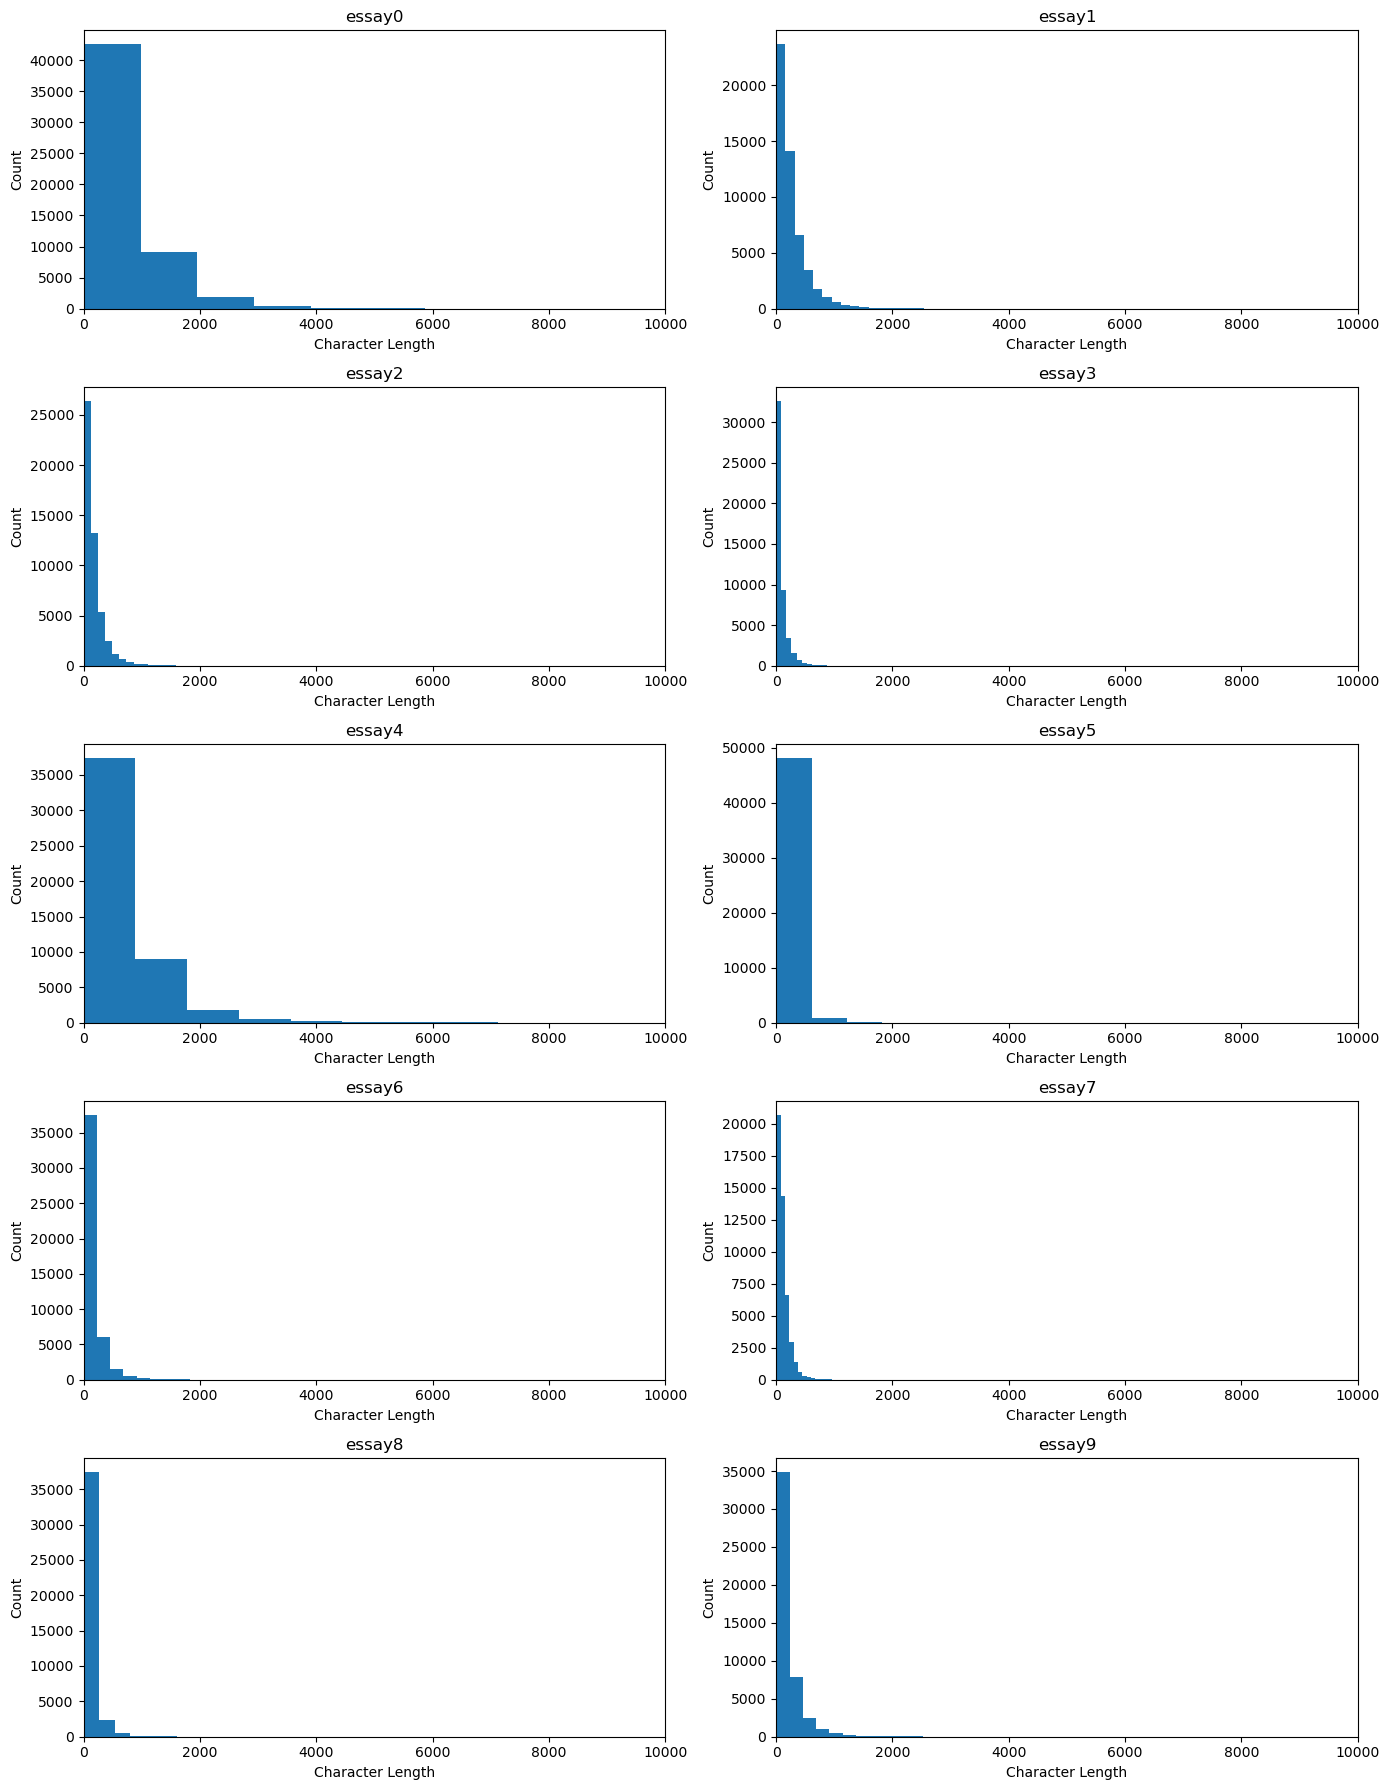

In [8]:
import matplotlib.pyplot as plt

essay_cols = [f"essay{i}" for i in range(10)]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(essay_cols):
    lengths = df[col].dropna().str.len()
    
    axes[i].hist(lengths, bins=50)
    axes[i].set_title(col)
    axes[i].set_xlim(0, 10000)
    axes[i].set_xlabel("Character Length")
    axes[i].set_ylabel("Count")

# Remove empty subplot if odd number
if len(essay_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [9]:
length_stats = []

for col in essay_cols:
    lengths = df[col].dropna().str.len()
    length_stats.append({
        "essay": col,
        "min_length": lengths.min(),
        "max_length": lengths.max(),
        "median_length": lengths.median(),
        "mean_length": lengths.mean()
    })

length_df = pd.DataFrame(length_stats)
length_df


,essay,min_length,max_length,median_length,mean_length
0,essay0,1,48854,479.0,678.977230
1,essay1,1,7955,182.0,269.345038
2,essay2,1,6129,116.0,173.516081
3,essay3,1,4374,54.0,91.146028
4,essay4,1,44469,472.0,683.127123
5,essay5,1,30446,104.0,147.503381
6,essay6,1,11385,87.0,152.201841
7,essay7,1,3722,88.0,118.979598
8,essay8,1,13304,60.0,109.978537
9,essay9,1,11444,113.0,200.758739


**Important points:**
- Heavily right-skewed data
- We dropped all the nan values but there might might be empty answers with white space, next line character or something irrelevant with min lenght as 1. Need to take care of that

#### Cleaning the Essay Data:

**Criteria to be meaningful:**

An essay is meaningful if:

- After stripping whitespace → length ≥ 40 characters
- Contains at least 15 alphabetic characters
- Is not just punctuation or repeated junk

In [10]:
import re
# Our Meaningful function
def is_meaningful(text, min_chars=40, min_alpha_chars=15):
    if pd.isna(text):
        return False
    
    text = text.strip()
    
    if len(text) < min_chars:
        return False
    
    alpha_count = len(re.findall(r"[a-zA-Z]", text))
    if alpha_count < min_alpha_chars:
        return False
    
    return True


In [11]:
essay_cols = [f"essay{i}" for i in range(10)]

edf = df[essay_cols].copy()

In [12]:
for col in essay_cols:
    edf[f"{col}_meaningful"] = edf[col].apply(is_meaningful)

meaningful_cols = [f"{col}_meaningful" for col in essay_cols]

edf["num_meaningful_essays"] = edf[meaningful_cols].sum(axis=1)

In [13]:
edf['num_meaningful_essays'].mean()

6.743752710773029

In [14]:
edf['num_meaningful_essays'].value_counts()

num_meaningful_essays
9     10771
10     9605
8      9446
7      7529
6      5919
5      4363
4      3215
0      2793
3      2325
1      2123
2      1857
Name: count, dtype: int64

So about 6-7 meaningful essays per user. Next we move on to filtering we are creating 3 types of baseline clusters
- Baseline 1: Users with all essays meaningful
- Baseline 2: Users with at least 5 meaningful essays
- Baseline 3: Users with at least 1 meaningful essay

In [15]:
edf_all = edf[edf["num_meaningful_essays"] == len(essay_cols)]
edf_5plus = edf[edf["num_meaningful_essays"] >= 5]
edf_1plus = edf[edf["num_meaningful_essays"] >= 1]

In [16]:
print("All meaningful:", edf_all.shape[0])
print(">=5 meaningful:", edf_5plus.shape[0])
print(">=1 meaningful:", edf_1plus.shape[0])

All meaningful: 9605
>=5 meaningful: 47633
>=1 meaningful: 57153


Great all of these clusters are decently sized so the plan ahead as stated eariler to create 3 clusters and analyse them

In [17]:
edf_all.head()

,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9,...,essay1_meaningful,essay2_meaningful,essay3_meaningful,essay4_meaningful,essay5_meaningful,essay6_meaningful,essay7_meaningful,essay8_meaningful,essay9_meaningful,num_meaningful_essays
11,"i was born in wisconsin, grew up in iowa, and ...",i'm currently the youngest member on an intern...,i'm really good at a little bit of everything....,"the way i dress. some days it's hats, other da...",books = yes. avid reader.<br />\nmoves = etern...,"guitar - even if i don't play it all the time,...",a little bit of everything. but mostly social ...,hanging out with a small group of friends--sta...,i'm picky when it comes to dating. i know what...,"if you know who you are, who you want, where y...",...,True,True,True,True,True,True,True,True,True,10
16,"i just moved to the bay area from austin, tx (...","making music, programming, getting back into a...","i'm from louisiana, so cooking and eating are ...","lately, i keep getting asked ""are you with the...",movies/tv/etc:<br />\nthe big lebowski (and ot...,(in no particular order)<br />\n<br />\n- good...,- methodologies for practicing creative skills...,i just moved here and am still getting to know...,i am in my 30's and still cannot grow a mustac...,you want to help me assemble ikea stuff and/or...,...,True,True,True,True,True,True,True,True,True,10
17,to sum myself in whole: i have adventurous ten...,i'm currently studying and majoring in crimina...,hmm...i know i can take a test rather well.;) ...,physically-i've been told my eyes. people usua...,i'm much more of a movie goer. favorite actor:...,my cellphone<br />\neye liner<br />\nfood<br /...,my next big vacation! who knows....maybe if i ...,"working out at the gym, sometimes watching a m...",i could beat you at a game of hold em'.....try...,you're interested?<br />\n<br />\nand you also...,...,True,True,True,True,True,True,True,True,True,10
18,some of my favorite things:<br />\nriding my m...,"enjoying it, exploring limits, looking for love","understanding, appreciating, i like getting a ...",blue eyes and a kind soul... although i don't ...,"i like stories that are adventurous, fun, and ...","compassion, love, art, my motorcycle, stretchi...",i like thinking about ways to improve things. ...,"last friday i had dinner with my roommates, an...",i have liked vampire novels ever since finding...,"because i'll try to write back, and it's hard ...",...,True,True,True,True,True,True,True,True,True,10
22,i tend to think the same way a comedian does a...,i'm a supply and demand manager for a sustaina...,"making predictions, planning anything (i'm pre...",that i'm smiling. pretty much at all times.,a confederacy of dunces and infinite jest are ...,"1) sf restaurants, could they be any better?<b...",how to build an empire and a legacy. so far th...,having beers with any number of friends and pr...,when i was a kid i thought steven segal was re...,you're a positive and creative personality loo...,...,True,True,True,True,True,True,True,True,True,10


### Stage 1 TF - IDF + Kmeans
After the EDA I plan to go on with these 3 stages
- First 3 baselines TF-IDF + Kmeans
- Next baseline sentence transformer + Kmeans
- Next baseline sentence transformer + HDBSCAN  --> Hoping to discover some real latent traits here 🤞

#### Essay Model Building - Version 1.0

The Clustering goal is: Discover latent self-presentation patterns across users

So the unit of clustering must be: users i.e each doc for tfidf is the doc of combined essay text from all users

In [18]:
essay_cols = [f"essay{i}" for i in range(10)]
#Step 1: combining the essays
def combine_essays(df):
    return (
        df[essay_cols]
        .fillna("")
        .agg(" ".join, axis=1)
    )
#Step 2: Cleaning the text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)      # remove HTML
    text = re.sub(r"\s+", " ", text)        # normalize whitespace
    return text.strip()

#Step 3: Tfidf model
def build_tfidf(texts, max_features=8000):
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=5,
        stop_words="english"
    )
    X = vectorizer.fit_transform(texts)
    return X, vectorizer
#Step 4: Running the kmeans model
def run_kmeans(X, k, random_state=42):
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=random_state
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    return model, labels, score
# Extract top terms per cluster
def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    centroids = model.cluster_centers_
    top_terms = {}
    for i, centroid in enumerate(centroids):
        top_idx = centroid.argsort()[::-1][:n_terms]
        top_terms[i] = terms[top_idx]
    return top_terms
# Qualitative Cluster Coherence
def representative_docs(X, texts, labels, model, n_docs=5):
    reps = {}
    for cluster_id in range(model.n_clusters):
        idx = np.where(labels == cluster_id)[0]
        distances = cosine_distances(X[idx], model.cluster_centers_[cluster_id].reshape(1, -1))
        closest = idx[distances.flatten().argsort()[:n_docs]]
        reps[cluster_id] = [texts[i][:500] for i in closest]
    return reps


In [19]:
def clustering_pipeline(df, cohort_name):
    print(f"\n=== Running pipeline for {cohort_name} ===")
    
    # Combine + clean
    raw_text = combine_essays(df)
    clean_texts = raw_text.apply(clean_text)
    
    # TF-IDF
    X, vectorizer = build_tfidf(clean_texts)
    
    results = {}
    
    for k in range(3, 9):
        model, labels, sil = run_kmeans(X, k)
        top_terms = top_terms_per_cluster(model, vectorizer)
        reps = representative_docs(X, clean_texts.tolist(), labels, model)
        
        results[k] = {
            "silhouette": sil,
            "model": model,
            "labels": labels,
            "top_terms": top_terms,
            "representative_docs": reps
        }
        
        print(f"k={k} | silhouette={sil:.4f}")
    
    return results

In [20]:
results_all   = clustering_pipeline(edf_all,   "All meaningful")
results_5plus = clustering_pipeline(edf_5plus, ">=5 meaningful")
results_1plus = clustering_pipeline(edf_1plus, ">=1 meaningful")


=== Running pipeline for All meaningful ===
k=3 | silhouette=0.0198
k=4 | silhouette=0.0381
k=5 | silhouette=0.0193
k=6 | silhouette=0.0189
k=7 | silhouette=0.0190
k=8 | silhouette=0.0190

=== Running pipeline for >=5 meaningful ===
k=3 | silhouette=0.0218
k=4 | silhouette=0.0198
k=5 | silhouette=0.0207
k=6 | silhouette=0.0209
k=7 | silhouette=0.0209
k=8 | silhouette=0.0098

=== Running pipeline for >=1 meaningful ===
k=3 | silhouette=0.0210
k=4 | silhouette=0.0203
k=5 | silhouette=0.0180
k=6 | silhouette=0.0177
k=7 | silhouette=0.0183
k=8 | silhouette=0.0179


#### Saving data for analysis later - Version 1.0

In [21]:
def silhouette_table(results, cohort):
    rows = []
    for k, info in results.items():
        rows.append({
            "cohort": cohort,
            "k": k,
            "silhouette": info["silhouette"]
        })
    return pd.DataFrame(rows)

sil_df = pd.concat([
    silhouette_table(results_all, "all_meaningful"),
    silhouette_table(results_5plus, "5plus_meaningful"),
    silhouette_table(results_1plus, "1plus_meaningful")
], ignore_index=True)

sil_df.sort_values(["cohort", "silhouette"], ascending=[True, False])


,cohort,k,silhouette
12,1plus_meaningful,3,0.020979
13,1plus_meaningful,4,0.020271
16,1plus_meaningful,7,0.018288
14,1plus_meaningful,5,0.017966
17,1plus_meaningful,8,0.017900
15,1plus_meaningful,6,0.017733
6,5plus_meaningful,3,0.021810
10,5plus_meaningful,7,0.020871
9,5plus_meaningful,6,0.020861
8,5plus_meaningful,5,0.020711


In [22]:
def top_terms_table(results, cohort):
    rows = []
    for k, info in results.items():
        for cluster_id, terms in info["top_terms"].items():
            rows.append({
                "cohort": cohort,
                "k": k,
                "cluster": cluster_id,
                "top_terms": ", ".join(terms)
            })
    return pd.DataFrame(rows)

terms_df = pd.concat([
    top_terms_table(results_all, "all_meaningful"),
    top_terms_table(results_5plus, "5plus_meaningful"),
    top_terms_table(results_1plus, "1plus_meaningful")
], ignore_index=True)

terms_df.head()


,cohort,k,cluster,top_terms
0,all_meaningful,3,0,"like, love, good, people, friends, life, just,..."
1,all_meaningful,3,1,"href interests, class ilink, ilink href, ilink..."
2,all_meaningful,3,2,"href interests, ilink href, ilink, class ilink..."
3,all_meaningful,4,0,"like, don, love, people, just, really, good, t..."
4,all_meaningful,4,1,"ilink, class ilink, href interests, ilink href..."


In [23]:
terms_df.to_csv("analysis_top_terms.csv", index=False)


In [24]:
def representative_docs_table(results, cohort):
    rows = []
    for k, info in results.items():
        for cluster_id, docs in info["representative_docs"].items():
            for i, doc in enumerate(docs):
                rows.append({
                    "cohort": cohort,
                    "k": k,
                    "cluster": cluster_id,
                    "example_id": i,
                    "text_snippet": doc
                })
    return pd.DataFrame(rows)

reps_df = pd.concat([
    representative_docs_table(results_all, "all_meaningful"),
    representative_docs_table(results_5plus, "5plus_meaningful"),
    representative_docs_table(results_1plus, "1plus_meaningful")
], ignore_index=True)

reps_df.head()

,cohort,k,cluster,example_id,text_snippet
0,all_meaningful,3,0,0,this is like when you get introduced to someon...
1,all_meaningful,3,0,1,if i rated you highly definitely send me a mes...
2,all_meaningful,3,0,2,i just want to find love someone to love and s...
3,all_meaningful,3,0,3,"this profile is in desperate need of revision,..."
4,all_meaningful,3,0,4,i was raised in portland by parents who were b...


In [25]:
reps_df.to_csv("analysis_representative_docs.csv", index=False)


**Points to be discussed :**
+ Cleaning Misses:
    - Some words were wrongly split like I've has been split as i , ve simillarly don't as don , t
    - Some HTML was present in the essays which was not properly extracted which casused tags like ilink, a, class also be considered as text
+ Silhouette score :
    - Almost all the clusters have very low score about near 0.0 meaning that all the clusters are not unique and mean the same thing
+ Top K tems and Representative Docs :
    - Didn't analyse all of them but the relation between top k terms and the representative documents was poor 


##### Next Steps:

We need to do recleaning of our essays and this time let's just proceed with the only the all_meaningful.

Initial preprocessing relied on regex-based HTML removal, which proved insufficient due to malformed and multiline HTML tags present in the raw dataset. This resulted in residual tag tokens dominating TF-IDF features. We therefore introduced a second preprocessing iteration using a proper HTML parser

#### Essay Model Building - Version 2.0

Here we will only be proceeding with all the meaningful user essays recleaning and using TF-IDF and kmeans again

In [26]:
%pip install contractions

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


##### Cleaning

In [27]:
from bs4 import BeautifulSoup
import html
import contractions
import re
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

def strip_html_and_entities(text):
    if pd.isna(text) or text is None:
        return ""
    clean = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    clean = html.unescape(clean)
    return clean

def normalize_contractions(text):
    try:
        return contractions.fix(text)
    except Exception:
        return text

def clean_text_v2(text):
    text = strip_html_and_entities(text)
    text = text.lower()
    text = normalize_contractions(text)
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

edf_all = edf_all.copy()   

edf_all["full_essay"] = (
    edf_all[essay_cols]
    .fillna("")
    .agg(" ".join, axis=1)
)

edf_all["clean_essay"] = edf_all["full_essay"].apply(clean_text_v2)

# Check duplicates
dups = edf_all["clean_essay"].duplicated().sum()
print("duplicate profiles (cleaned text):", dups)

edf_all = edf_all[~edf_all["clean_essay"].duplicated()].reset_index(drop=True)

cv = CountVectorizer(
    token_pattern=r"(?u)\b\w[\w']+\b",
    max_features=2000,
    stop_words="english"
)

Xc = cv.fit_transform(edf_all["clean_essay"])

token_counts = pd.DataFrame({
    "token": cv.get_feature_names_out(),
    "count": Xc.sum(axis=0).A1
}).sort_values("count", ascending=False)

token_counts.head(30)


duplicate profiles (cleaned text): 0


,token,count
1030,like,38956
1066,love,31304
750,good,24769
1302,people,23982
951,just,20654
1182,music,20552
1806,time,20438
686,friends,20008
1025,life,19502
1794,things,19247


Ok now we removed all the html junk tags and cleaned the contractions let's proceed with TF-IDF and Kmeans again

##### Building the pipeline 

In [28]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    stop_words="english"
)

X = tfidf.fit_transform(edf_all["clean_essay"])
print("TF-IDF shape:", X.shape)

def top_terms_per_cluster(tfidf_model, X, labels, k, n_terms=15):
    feature_names = tfidf_model.get_feature_names_out()
    df = pd.DataFrame(X.toarray(), columns=feature_names)
    df["cluster"] = labels
    
    top_terms = {}
    for cluster_id in range(k):
        mean_tfidf = df[df["cluster"] == cluster_id].drop("cluster", axis=1).mean()
        top_terms[cluster_id] = mean_tfidf.sort_values(ascending=False).head(n_terms).index.tolist()
    return top_terms

def representative_docs(X, texts, labels, model, n_docs=5):
    reps = {}
    for cluster_id in range(model.n_clusters):
        idx = np.where(labels == cluster_id)[0]
        distances = cosine_distances(
            X[idx],
            model.cluster_centers_[cluster_id].reshape(1, -1)
        )
        closest = idx[distances.flatten().argsort()[:n_docs]]
        reps[cluster_id] = [texts[i][:500] for i in closest]
    return reps


TF-IDF shape: (9605, 10000)


##### Training the model

In [29]:
results = []

for k in range(3, 8):
    print(f"\n=== k = {k} ===")
    
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X)
    
    sil = silhouette_score(X, labels)
    print(f"Silhouette score: {sil:.4f}")
    
    top_terms = top_terms_per_cluster(tfidf, X, labels, k)
    reps = representative_docs(X, edf_all["clean_essay"].values, labels, kmeans)
    
    results.append({
        "k": k,
        "silhouette": sil,
        "model": kmeans,
        "labels": labels,
        "top_terms": top_terms,
        "representative_docs": reps
    })



=== k = 3 ===
Silhouette score: 0.0007

=== k = 4 ===
Silhouette score: 0.0005

=== k = 5 ===
Silhouette score: -0.0004

=== k = 6 ===
Silhouette score: 0.0004

=== k = 7 ===
Silhouette score: -0.0004


Why score decreased after cleaning again?



##### Analysis

In [30]:
res_k4 = next(r for r in results if r["k"] == 4)

for cluster_id in range(4):
    print(f"\n--- Cluster {cluster_id} ---")
    print("Top terms:", res_k4["top_terms"][cluster_id])
    print("\nRepresentative docs:")
    for doc in res_k4["representative_docs"][cluster_id]:
        print("-", doc[:300])



--- Cluster 0 ---
Top terms: ['just', 'really', 'things', 'know', 'think', 'want', 'life', 'lot', 'pretty', 'going', 'games', 'food', 'movies', 'say', 'make']

Representative docs:
- fyi this profile is under slight work mostly making many 'maybes' into 'absolutes' let us get this ball rolling i am a 23 year old male but hell anyone can find that info so how about i give you all those juicy tidbits you are not finding on the top of the page still with me good if it is bolded i t
- this is like when you get introduced to someone by a friend who has been talking a lot about how funny you are and the new person says say something funny okay i am funny i refuse to take anything seriously for more information on why ask me about the day i was riding my bike in the rain i am smart 
- 6 11 see my journal entry about the issue in regards to match question answers of the this question is irrelevant to you option hint being willing to accept answers that are not your preference means you are a 

The TF-IDF + KMeans baseline provided a sanity check but resulted in very low silhouette scores and clusters dominated by high-frequency, generic self-descriptive terms (e.g., “life”, “things”, “really”). While representative documents exhibited some thematic differences, cluster boundaries were highly overlapping due to TF-IDF’s reliance on surface-level lexical similarity.

Since dating profiles often express similar ideas using varied phrasing, a semantic representation that captures meaning beyond exact word overlap is more appropriate. Therefore, we next employ sentence-level transformer embeddings to model semantic similarity between user profiles before clustering.

### Stage 2 Sentence Transforment + Kmeans

Removing short docs helps in imporving the interpretability

#### Short Sanity Check

In [31]:
edf_all['clean_essay'].head().str.len()

0    4390
1    3555
2    3874
3    1861
4    1993
Name: clean_essay, dtype: int64

In [32]:
edf_all["doc_len"] = edf_all["clean_essay"].str.len()
edf_all["doc_len"].describe()
(edf_all["doc_len"] < 100).mean() 

0.0

So almost no documents found which have very short text this is a good sign to use sentence transformer

#### Pipeline

In [33]:
%pip install -U sentence-transformers plotly

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/570.8 kB ? eta -:--:--
   -------- ------------------------------- 122.9/570.8 kB 3.6 MB/s eta 0:00:01
   -------------------- ------------------- 286.7/570.8 kB 3.5 MB/s eta 0:00:01
   ----------------------------------- ---- 512.0/570.8 kB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 570.8/570.8 kB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
    --------------------------------------- 0.2/9.9 MB 5.3 MB/s eta 0:00:02
   - -------------------------------------- 0.4/9.9 MB 6.8 MB/s eta 0:00:02
   - -------------------------------------- 0.4/9.9 MB 6.8 MB/s eta 0:00:02
   -- ------------------------------------- 0.7/9.9 MB 3.9 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.9 MB 4.4 MB/s eta 0:00:03
   ---- ----------------------------------- 1.1/9.9 MB 4.1 MB/s eta 0:00:03
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


**Choice of sentence transformer**

We have chosen `all-mpnet-base-v2` as our sentence transformer model becuase of its context window being 512 tokens despite the average length of the combined essays being 670 words (~900 tokens) as it is faster to run on my laptop. 

Advanced Option (Improvements that could be made) :-

We split the 900-token essay into two 450-token chunks, pass both through MPNet, and then average the two 768-dimensional vectors together to create a single "master vector" for that user.But slow

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import joblib 
import os

# ---- CONFIG ----
TEXT_COL = "clean_essay"      
MIN_DOC_LENGTH = None   
EMB_MODEL = "all-mpnet-base-v2" 
PCA_DIMS = 64                 # reduce dims for KMeans (helps speed + denoise). Set None to skip PCA.
K_RANGE = range(3, 8)         # 3..7
TOP_TERMS = 15
REP_DOCS = 5

# ---- Prepare docs ----
df_work = edf_all.copy()
if MIN_DOC_LENGTH is not None:
    df_work = df_work[df_work[TEXT_COL].str.len() >= MIN_DOC_LENGTH].reset_index(drop=True)

texts = df_work[TEXT_COL].astype(str).tolist()
n_docs = len(texts)
print("Documents:", n_docs)

# ---- Embeddings ----
print("Loading model:", EMB_MODEL)
model = SentenceTransformer(EMB_MODEL)

print("Encoding texts (will show a progress bar)...")
embs = model.encode(texts, show_progress_bar=True, batch_size=64, convert_to_numpy=True)
print("Embeddings shape:", embs.shape)

# ---- PCA ----
if PCA_DIMS is not None:
    print(f"Reducing embeddings to {PCA_DIMS} dims with PCA...")
    pca = PCA(n_components=PCA_DIMS, random_state=42)
    embs_reduced = pca.fit_transform(embs)
    print("Reduced shape:", embs_reduced.shape)
else:
    embs_reduced = embs

# ---- Build TF-IDF once for top-term extraction ----
print("Fitting TF-IDF on cleaned texts (for cluster keywords)...")
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=5, stop_words="english")
X_tfidf = tfidf.fit_transform(texts)
feature_names = tfidf.get_feature_names_out()

# ---- helper functions ----
def cluster_top_terms_from_tfidf(X_tfidf, labels, feature_names, topn=15):
    """Given tfidf matrix (full corpus) and labels, return top terms per cluster."""
    rows = {}
    labels_arr = np.array(labels)
    for lab in sorted(np.unique(labels_arr)):
        if lab == -1:  # skip noise if present
            continue
        idx = np.where(labels_arr == lab)[0]
        if len(idx) == 0:
            rows[lab] = []
            continue
        mean_vec = X_tfidf[idx].mean(axis=0).A1
        top_idx = mean_vec.argsort()[::-1][:topn]
        rows[lab] = feature_names[top_idx].tolist()
    return rows

def rep_docs_by_embedding(embs_full, texts, labels, model_centroid='orig', n=5):
    """Return n representative docs per cluster (closest to centroid in original embedding space)."""
    reps = {}
    labels_arr = np.array(labels)
    for lab in sorted(set(labels_arr)):
        if lab == -1:
            continue
        idx = np.where(labels_arr == lab)[0]
        centroid = embs_full[idx].mean(axis=0).reshape(1, -1)
        dists = cosine_distances(embs_full[idx], centroid).flatten()
        closest = idx[dists.argsort()[:n]]
        reps[lab] = [texts[i][:500] for i in closest]
    return reps

# ---- Run KMeans for k in K_RANGE ---
results = {} 

for k in K_RANGE:
    print("\n--- Running KMeans k =", k, "---")
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(embs_reduced)
    
    try:
        sil = silhouette_score(embs_reduced, labels, metric='cosine')
    except Exception as e:
        print("Silhouette error:", e)
        sil = None
    print("Silhouette (cosine):", sil)
    
    top_terms = cluster_top_terms_from_tfidf(X_tfidf, labels, feature_names, topn=TOP_TERMS)
    reps = rep_docs_by_embedding(embs, texts, labels, n=REP_DOCS)
    
    # Save directly to the dictionary
    results[k] = {
        "k": k,
        "silhouette": sil,
        "model": km,
        "labels": labels,
        "top_terms": top_terms,
        "representative_docs": reps
    }

# ---- Summarize results to DataFrames ----
sil_rows = []
terms_rows = []
rep_rows = []

# [FIX 3]: Iterate over dictionary items instead of a list
for k, r in results.items(): 
    sil_rows.append({"k": k, "silhouette": r["silhouette"], "n_docs": n_docs})
    for cid, terms in r["top_terms"].items():
        terms_rows.append({"k": k, "cluster": cid, "top_terms": ", ".join(terms)})
    for cid, docs in r["representative_docs"].items():
        for i, doc in enumerate(docs):
            rep_rows.append({"k": k, "cluster": cid, "example_id": i, "text_snippet": doc})

sil_df = pd.DataFrame(sil_rows).sort_values("k").reset_index(drop=True)
terms_df = pd.DataFrame(terms_rows)
reps_df = pd.DataFrame(rep_rows)

out_dir = "clustering_embeddings_results"
os.makedirs(out_dir, exist_ok=True)
sil_df.to_csv(os.path.join(out_dir, "silhouettes_embeddings.csv"), index=False)
terms_df.to_csv(os.path.join(out_dir, "top_terms_embeddings.csv"), index=False)
reps_df.to_csv(os.path.join(out_dir, "representative_docs_embeddings.csv"), index=False)
joblib.dump(results, os.path.join(out_dir, "results_emb_k3_7.joblib"))

print("\nSaved results to", out_dir)
print("\nSilhouette summary:")
print(sil_df)

# Print a readable example for k=4
k_view = 4
if k_view in results:
    res_k = results[k_view]
    print(f"\nExample cluster overview for k={k_view}:")
    for cid in sorted(res_k["top_terms"].keys()):
        print(f"\nCluster {cid} top terms:", res_k["top_terms"][cid][:15])
        print("Representative doc 0:", res_k["representative_docs"][cid][0][:400])

Documents: 9605
Loading model: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding texts (will show a progress bar)...


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

Embeddings shape: (9605, 768)
Reducing embeddings to 64 dims with PCA...
Reduced shape: (9605, 64)
Fitting TF-IDF on cleaned texts (for cluster keywords)...

--- Running KMeans k = 3 ---
Silhouette (cosine): 0.13566497

--- Running KMeans k = 4 ---
Silhouette (cosine): 0.1263538

--- Running KMeans k = 5 ---
Silhouette (cosine): 0.117996454

--- Running KMeans k = 6 ---
Silhouette (cosine): 0.115307644

--- Running KMeans k = 7 ---
Silhouette (cosine): 0.094596915

Saved results to clustering_embeddings_results

Silhouette summary:
   k  silhouette  n_docs
0  3    0.135665    9605
1  4    0.126354    9605
2  5    0.117996    9605
3  6    0.115308    9605
4  7    0.094597    9605

Example cluster overview for k=4:

Cluster 0 top terms: ['love', 'like', 'good', 'life', 'people', 'just', 'time', 'friends', 'things', 'really', 'music', 'looking', 'want', 'know', 'new']
Representative doc 0: i am an active lively and social person with a fairly curious mind i am a student at heart i am reas

The Silhouette score did increase but not by something really huge, expected to be less since it's a high dimensional space.

The terms are still generic let's try to read and analyse the documents for k = 3 and find if there is any latent 

In [35]:
def get_representative_docs(
    embeddings,
    texts,
    labels,
    k,
    n_docs=5
):
    reps = {}
    for cluster_id in range(k):
        idx = np.where(labels == cluster_id)[0]
        cluster_embs = embeddings[idx]
        centroid = cluster_embs.mean(axis=0, keepdims=True)

        distances = cosine_distances(cluster_embs, centroid).flatten()
        closest = idx[np.argsort(distances)[:n_docs]]

        reps[cluster_id] = [texts[i] for i in closest]
    return reps

k = 3
labels_k3 = results[k]["labels"]
emb_k3 = embs_reduced
texts = edf_all["clean_essay"].tolist()

rep_docs = get_representative_docs(
    embeddings=emb_k3,
    texts=texts,
    labels=labels_k3,
    k=k,
    n_docs=10
)

In [36]:
for cluster_id, docs in rep_docs.items():
    print(f"\n=== Cluster {cluster_id} ===\n")
    for i, doc in enumerate(docs, 1):
        print(f"[Doc {i}] {doc[:1000]}...\n")


=== Cluster 0 ===

[Doc 1] hi my name is priscilla i seem to be looking for love in all the wrong places so here i am on this world wide web search for companionship i enjoy great conversation a kick ass sense of humor and a great kisser i like to try new things i consider myself a very spontaneous person game for whatever i am in a chapter of my life where i welcome new experiences and people i love to travel although i really do not mind traveling by myself some company would be great too i respect an honest man who tells it like it is and is not a liar someone who swears to tell the truth the whole truth and nothing but the truth lol i would like a real man no fakes no phonies please a man's man who is not possessive or aggressive i would like somebody who does not have a severe case of the home body blues i am kind of over the bar scene nightlife but would not mind someone who will join me from time to time if the night get's a little wild p but hopefully most of our time will be 

##### Analysing the Documents for each cluster

Some thing interesting I found

+ Cluster 0

All of the users in this cluster(upto Doc 10) explicitely state what they do not what. They are aggressively filtering out casual dating.It represents the users who are older or like settled who are past the party age. Mostly mature and High intent seekers.

+ Cluster 1

All users in this cluster(upto Doc 10) seem to have moved to San Francisco and they are obsessed with exploring it. They are highly active and have lots of positive energy which is seen in their communication style.Also this cluster is dominated by highly educated, career-focused individuals working in very "San Francisco" industries: startups, non-profits, design, and advertising.

+ Cluster 2

All the users in this cluster(upto Doc 10) seems to be explicitly embrace being outside the mainstream. They wear their niche interests like badges of honor. They seems to be creative crowd with like musicians, writers, artists etc. 

All in all this looks pretty convincing but you can say it holds true for the entire cluster just by reading the top 10 documents a formal way to prove or experiment this is needed.

Different methods to actually verify if there is similarities withing the group:-
- Intra-cluster similarity vs inter-cluster similarity
- Label-blind annotation sanity check
Randomly sample 15–20 profiles
Remove cluster labels
Ask:
“Which of these feel similar in tone/intent?”

I will be doing the first one as its more mathematical and easy to implement.The second one there might be a bias if done by myself

#### Inter Vs Intra cluster similarties

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

def cluster_similarity_stats(embs, labels, n_samples=200, random_state=42):
    rng = np.random.default_rng(random_state)
    clusters = np.unique(labels)

    intra_sims = []
    inter_sims = []

    for c in clusters:
        idx = np.where(labels == c)[0]
        if len(idx) < 2:
            continue

        sample_idx = rng.choice(idx, size=min(n_samples, len(idx)), replace=False)
        sim = cosine_similarity(embs[sample_idx])
        intra_sims.append(sim[np.triu_indices_from(sim, k=1)].mean())

    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            idx_i = np.where(labels == clusters[i])[0]
            idx_j = np.where(labels == clusters[j])[0]

            si = rng.choice(idx_i, size=min(n_samples, len(idx_i)), replace=False)
            sj = rng.choice(idx_j, size=min(n_samples, len(idx_j)), replace=False)

            sim = cosine_similarity(embs[si], embs[sj])
            inter_sims.append(sim.mean())

    return {
        "intra_cluster_similarity": np.mean(intra_sims),
        "inter_cluster_similarity": np.mean(inter_sims),
        "gap": np.mean(intra_sims) - np.mean(inter_sims)
    }


In [38]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(embs_reduced)

stats = cluster_similarity_stats(embs_reduced, labels)

print("Intra-cluster similarity :", stats["intra_cluster_similarity"])
print("Inter-cluster similarity :", stats["inter_cluster_similarity"])
print("Similarity gap           :", stats["gap"])


Intra-cluster similarity : 0.13618065
Inter-cluster similarity : -0.061092947
Similarity gap           : 0.1972736


To validate cluster coherence beyond silhouette score, we computed average cosine similarity between sentence embeddings within clusters and compared it to similarity across clusters. For k=3, intra-cluster similarity was positive (0.13) while inter-cluster similarity was negative (−0.061), yielding a substantial similarity gap of 0.19. This indicates that profiles grouped together are semantically aligned, while profiles from different clusters are meaningfully dissimilar. This result provides quantitative evidence that the discovered clusters reflect genuine latent structure rather than random partitioning.

#ADD Visulisation

### Stage 3 Sentence Transformer + HDBSCAN

#### Version 1.0

In [39]:
%pip install hdbscan


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [40]:
import hdbscan

In [41]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(embs_reduced)


In [42]:
edf_all["hdbscan_label"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("Clusters found:", n_clusters)
print("Noise points:", n_noise)
print("Noise percentage:", n_noise / len(labels))


Clusters found: 0
Noise points: 9605
Noise percentage: 1.0


In [43]:
edf_all["hdbscan_label"].value_counts().sort_index()


hdbscan_label
-1    9605
Name: count, dtype: int64

In [44]:
def hdbscan_representatives(embs, labels, texts, cluster_id, n_docs=5):
    idx = np.where(labels == cluster_id)[0]
    center = embs[idx].mean(axis=0, keepdims=True)
    sims = cosine_similarity(embs[idx], center).flatten()
    top = idx[np.argsort(-sims)[:n_docs]]
    return [texts[i][:500] for i in top]


In [45]:
for cid in sorted(set(labels)):
    if cid == -1:
        continue
    print(f"\n=== Cluster {cid} ===")
    reps = hdbscan_representatives(embs_reduced, labels, edf_all["clean_essay"].tolist(), cid)
    for i, r in enumerate(reps, 1):
        print(f"[Doc {i}]", r[:300])


In [46]:
stats = cluster_similarity_stats(embs_reduced, labels)
print(stats)


{'intra_cluster_similarity': 0.00750294, 'inter_cluster_similarity': nan, 'gap': nan}


C:\Users\magan\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\magan\AppData\Roaming\Python\Python311\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [47]:
clusterer.cluster_persistence_


array([], dtype=float64)

So definitely something wrong happened here as the intra cluster similarity is very low and obviously all the users don't fit into a single cluster. The reasons what I am thinking are PCA reduced 64 dimensions which is still astronomically large. In high-dimensional space, data points spread out so much that the distance between any two random points becomes roughly equal. Because the space is so sparsely populated, HDBSCAN cannot find any tight "neighborhoods" that meet its minimum cluster size and density thresholds. Therefore, it mathematically assumes everything is an outlier. 
 

#### Version 2.0 Sentence Transformer + UMAP + HBDSCAN

In [48]:
%pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


UMAP Step(Add Some description about UMAP and how it is going to help us)



In [ ]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,        # local neighborhood size
    n_components=10,       # 5–15 is typical
    min_dist=0.0,          # encourages tight clusters
    metric="cosine",
    random_state=42
)

embs_umap = umap_model.fit_transform(embs)


C:\Users\magan\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Building the HDBSCAN model 

In [ ]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,      
    min_samples=10,           
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(embs_umap)
edf_all["hdbscan_label"] = labels

Inspecting the values

In [51]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("Clusters found:", n_clusters)
print("Noise points:", n_noise)
print("Noise percentage:", n_noise / len(labels))

Clusters found: 7
Noise points: 5110
Noise percentage: 0.5320145757418011


Better than v1.0 where we got everything classified as noise let's look at each cluster size and read the documents in each cluster here

Analysis

In [52]:
#Finding each cluster size
cluster_sizes = (
    pd.Series(labels)
    .value_counts()
    .sort_index()
)

cluster_sizes

-1    5110
 0      66
 1      63
 2    1608
 3      77
 4      79
 5      58
 6    2544
Name: count, dtype: int64

In [53]:
#Top terms in each cluster. We already wrote code for getting representative docs in v1.0.
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

X_tfidf = tfidf.fit_transform(edf_all["clean_essay"])
terms = tfidf.get_feature_names_out()

def hdbscan_top_terms(X_tfidf, labels, terms, cluster_id, top_k=15):
    idx = np.where(labels == cluster_id)[0]
    if len(idx) == 0:
        return []

    cluster_mean = X_tfidf[idx].mean(axis=0).A1
    top_idx = np.argsort(cluster_mean)[-top_k:][::-1]
    return [terms[i] for i in top_idx]

In [54]:
#Printing the Docs + Top terms.
texts = edf_all["clean_essay"].tolist()

for cid in sorted(set(labels)):
    if cid == -1:
        continue

    print(f"\n=== Cluster {cid} ===")

    top_terms = hdbscan_top_terms(X_tfidf, labels, terms, cid)
    print("Top terms:", top_terms)

    reps = hdbscan_representatives(
        embs_reduced,
        labels,
        texts,
        cid,
        n_docs=10
    )# Reusing the function already defined

    for i, doc in enumerate(reps, 1):
        print(f"[Doc {i}]", doc[:1000])


=== Cluster 0 ===
Top terms: ['like', 'really', 'just', 'things', 'people', 'self', 'love', 'good', 'life', 'time', 'summary', 'think', 'music', 'know', 'self summary']
[Doc 1] not only am i lousy at self summaries i just do not like them i would far rather play twenty questions as i get to know someone i would have friends write a summary but then it would not be self would it hrm what a quandary let me try a couple bullets divorced but have a very good relationship with my ex father of the coolest daughter around moved to the bay area from the east coast in 2010 and loving it working in it along with seemingly half the rest of silicon valley i am a smartass who does 
[Doc 2] i have never been good at writing self summaries i am a transplant to the city looking to make friends have fun and make the most of my time here i am generally good natured i love to laugh i am a leo and i am always looking for an adventurous hiking buddy i am a bit of a social chameleon i fit into all sorts of

My Interpretations: 

+ Cluster 0 size 66
    - This entire cluster shares a distinct common feature - complaining about the essay prompt itself. A lot of their text is discussing how difficult it is to summarize themselves

+ Cluster 1 size 63
    - This entire cluster focuses a lot on spirituality. The language is intense and heavily focussed on energy  and somatic experiences.

+ Cluster 2 size 1608 
    - This cluster contains profiles who are highly introspective, eccentric. They use high level vocab to describe their niche interests . This is similar to the profiles we got in KMeans

+ Cluster 3 size 77
    - This cluster contains users who describe themselves as very approachable. They have very mainstream hobbies and give very regulary descriptions about themseleves.

+ Cluter 4 size 79
    - This cluster captured a lot of users who stated their gender identity, sexual orientation, and non-traditional relationship structures upfront to filter out incompatible matches.

+ Cluter 5 size 58
    - This group contains users who started their essays with their origin stories combined with high educational or career achievements.
    Eg:- "us peace corps in the dominican republic... study law," "moved to the bay area three years ago... banking finance," "masters at cal," "graduate school at stanford."

+ Cluter 6 size 2544
    - Unlike cluster 5 who were focused a lot on career here the users focus entirely on the active california lifestyle. Their essays are mostly on physical activities, food and how they enjoy the region.

What about the noise - 5110 profiles?

So these are the profiles which didn't fit into any of the clusters above they might be too individualistic and since the questions which were asked for the essays are very open. Basically the latent space vectors of these individuals might span across many dimensions without forming a dense cluster so the model classified them as noise.

Next I would like to do a deeper analysis in these clusters by calculating metrics such as:- 
- Average essay length per cluster
- Lexical diversity (unique tokens / total tokens)
- TF-IDF entropy (how concentrated vs diffuse vocabulary is)

In [55]:
def lexical_diversity(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

edf_all["essay_len"] = edf_all["clean_essay"].str.split().str.len()
edf_all["lex_div"] = edf_all["clean_essay"].apply(lexical_diversity)

cluster_stats = (
    edf_all
    .assign(cluster=labels)
    .groupby("cluster")
    .agg(
        n_profiles=("clean_essay", "count"),
        avg_len=("essay_len", "mean"),
        avg_lex_div=("lex_div", "mean")
    )
    .sort_values("n_profiles", ascending=False)
)

print(cluster_stats)


         n_profiles     avg_len  avg_lex_div
cluster                                     
-1             5110  686.077495     0.541712
 6             2544  669.536557     0.531925
 2             1608  649.754975     0.553215
 4               79  840.278481     0.526092
 3               77  717.701299     0.510589
 0               66  830.378788     0.520642
 1               63  732.904762     0.525006
 5               58  606.465517     0.592134


+ Cluster 0 They have the second highest avg len of essays as they start by complaining how hard it is to write essay and spend a lot of words on that.

+ Cluster 1 moderate avg len and lex diversity.

+ Cluster 2 Second highest lex diversity as they have a lot of niche interests and use high level vocab to describe them.

+ Cluster 3 Lowest lex diversity as they use standard, simple, everyday language without trying to sound overly academic or eccentric.

+ Cluster 4 has the longest essays this perfectly aligns with our observation that this group uses their profiles to establish clear boundaries

+ Cluster 5 has the highest Lexical Diversity but the shortest essays.Most of the individuals in this focussed a lot on their career so they write concise but use a wide vocabulary.

+ Cluster 6 moderate length and lexical diversity among them

In [56]:
from scipy.stats import entropy

def tfidf_entropy(tfidf_matrix):
    row_sums = tfidf_matrix.sum(axis=1).A1
    row_sums = np.maximum(row_sums, 1e-9).reshape(-1, 1)
    probs = tfidf_matrix.multiply(1 / row_sums)
    probs = probs.tocsr()
    return np.array([
        entropy(probs[i].data) if probs[i].nnz > 0 else 0.0
        for i in range(probs.shape[0])
    ])
    
edf_all["tfidf_entropy"] = tfidf_entropy(X_tfidf)
edf_all["cluster"] = labels

edf_all.groupby("cluster")["tfidf_entropy"].agg(
    ["mean", "std", "count"]
)



,mean,std,count
cluster,,,
-1,5.399633,0.402887,5110
0,5.482330,0.454047,66
1,5.372889,0.445514,63
2,5.365257,0.393150,1608
3,5.406803,0.437610,77
4,5.472993,0.449995,79
5,5.466403,0.259763,58
6,5.381807,0.416732,2544


In [57]:
def hdbscan_intra_inter_gap(embeddings, labels):
    """
    embeddings: np.ndarray (N, D)
    labels: np.ndarray (N,)
    """

    unique_clusters = [c for c in np.unique(labels) if c != -1]

    intra_sims = []
    inter_sims = []

    for c in unique_clusters:
        idx_c = np.where(labels == c)[0]
        idx_not_c = np.where((labels != c) & (labels != -1))[0]

        if len(idx_c) < 2 or len(idx_not_c) == 0:
            continue

        # --- Intra-cluster similarity ---
        sims_intra = cosine_similarity(
            embeddings[idx_c],
            embeddings[idx_c]
        )

        # remove diagonal (self-similarity = 1)
        intra_vals = sims_intra[np.triu_indices_from(sims_intra, k=1)]
        intra_sims.append(intra_vals.mean())

        # --- Inter-cluster similarity ---
        sims_inter = cosine_similarity(
            embeddings[idx_c],
            embeddings[idx_not_c]
        )
        inter_sims.append(sims_inter.mean())

    return {
        "mean_intra_similarity": np.mean(intra_sims),
        "mean_inter_similarity": np.mean(inter_sims),
        "gap": np.mean(intra_sims) - np.mean(inter_sims),
    }

gap_stats = hdbscan_intra_inter_gap(
    embeddings=embs_reduced,
    labels=edf_all["hdbscan_label"].values
)

gap_stats


{'mean_intra_similarity': 0.2853139,
 'mean_inter_similarity': -0.039371423,
 'gap': 0.32468534}

### Stage 4 Demographic Features + Our latent Features model

Let's get a quick overlook of the data with which we are working

In [58]:
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
import itertools
sns.set(style="whitegrid", context="notebook")

cluster_col = "cluster" 
print("Unique clusters:", sorted(edf_all[cluster_col].unique()))
print("Cluster sizes:")
print(edf_all[cluster_col].value_counts().sort_index())

Unique clusters: [-1, 0, 1, 2, 3, 4, 5, 6]
Cluster sizes:
cluster
-1    5110
 0      66
 1      63
 2    1608
 3      77
 4      79
 5      58
 6    2544
Name: count, dtype: int64


We need to merge our clustered labels and numeric features all into one dataframe for analysis let's label it df_clustered.

In [59]:
essay_cols = ['essay0', 'essay1', 'essay2', 'essay3', 'essay4', 
              'essay5', 'essay6', 'essay7', 'essay8', 'essay9']

df_clustered = df.merge(
    edf_all[['essay0', 'essay1', 'essay2', 'essay3', 'essay4', 
             'essay5', 'essay6', 'essay7', 'essay8', 'essay9',
             'full_essay', 'clean_essay', 'doc_len', 'hdbscan_label', 
             'essay_len', 'lex_div', 'tfidf_entropy', 'cluster']], 
    on=essay_cols,
    how='inner'  
)

# Check the result
print(f"Rows in df_clustered: {len(df_clustered)}")  # Should be 9,605
df_clustered = df_clustered.dropna(subset=[cluster_col])
print(f"Original df: {len(df)} rows")
print(f"edf_all (all meaningful): {len(edf_all)} rows")
print(f"After merge with clusters: {len(df_clustered)} rows")
df_clustered.head()

Rows in df_clustered: 9605
Original df: 59946 rows
edf_all (all meaningful): 9605 rows
After merge with clusters: 9605 rows


,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,speaks,status,full_essay,clean_essay,doc_len,hdbscan_label,essay_len,lex_div,tfidf_entropy,cluster
0,28,average,mostly anything,socially,never,graduated from college/university,"i was born in wisconsin, grew up in iowa, and ...",i'm currently the youngest member on an intern...,i'm really good at a little bit of everything....,"the way i dress. some days it's hats, other da...",...,"english (fluently), sign language (poorly)",seeing someone,"i was born in wisconsin, grew up in iowa, and ...",i was born in wisconsin grew up in iowa and mo...,4390,-1,862,0.437355,5.672571,-1
1,33,fit,NaN,socially,NaN,working on masters program,"i just moved to the bay area from austin, tx (...","making music, programming, getting back into a...","i'm from louisiana, so cooking and eating are ...","lately, i keep getting asked ""are you with the...",...,"english (fluently), c++ (fluently), german (po...",single,"i just moved to the bay area from austin, tx (...",i just moved to the bay area from austin tx or...,3555,6,683,0.478770,5.443912,6
2,26,average,NaN,socially,never,working on college/university,to sum myself in whole: i have adventurous ten...,i'm currently studying and majoring in crimina...,hmm...i know i can take a test rather well.;) ...,physically-i've been told my eyes. people usua...,...,english,single,to sum myself in whole: i have adventurous ten...,to sum myself in whole i have adventurous tend...,3874,-1,737,0.507463,5.576659,-1
3,31,average,mostly vegetarian,rarely,never,graduated from space camp,some of my favorite things:<br />\nriding my m...,"enjoying it, exploring limits, looking for love","understanding, appreciating, i like getting a ...",blue eyes and a kind soul... although i don't ...,...,english (fluently),single,some of my favorite things:<br />\nriding my m...,some of my favorite things riding my motorcycl...,1861,2,350,0.551429,4.797376,2
4,30,fit,mostly anything,socially,never,graduated from college/university,i tend to think the same way a comedian does a...,i'm a supply and demand manager for a sustaina...,"making predictions, planning anything (i'm pre...",that i'm smiling. pretty much at all times.,...,"english, spanish (poorly)",single,i tend to think the same way a comedian does a...,i tend to think the same way a comedian does a...,1993,-1,372,0.629032,5.009774,-1


In [60]:
df_clustered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9605 entries, 0 to 9604
Data columns (total 39 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            9605 non-null   int64  
 1   body_type      8824 non-null   object 
 2   diet           6086 non-null   object 
 3   drinks         9400 non-null   object 
 4   drugs          7284 non-null   object 
 5   education      9045 non-null   object 
 6   essay0         9605 non-null   object 
 7   essay1         9605 non-null   object 
 8   essay2         9605 non-null   object 
 9   essay3         9605 non-null   object 
 10  essay4         9605 non-null   object 
 11  essay5         9605 non-null   object 
 12  essay6         9605 non-null   object 
 13  essay7         9605 non-null   object 
 14  essay8         9605 non-null   object 
 15  essay9         9605 non-null   object 
 16  ethnicity      8957 non-null   object 
 17  height         9604 non-null   float64
 18  income  

#### Numerical analysis

Here we will be doing the numerical analysis of our variables

In [61]:
print(df_clustered['age'].describe())
median_value = df_clustered['age'].median()
print(f"Median of age: {median_value}")
mode_value = df_clustered["age"].mode()
print(f"Mode of age:  {mode_value.values}")

count    9605.000000
mean       32.585008
std         9.312106
min        18.000000
25%        26.000000
50%        30.000000
75%        37.000000
max        69.000000
Name: age, dtype: float64
Median of age: 30.0
Mode of age:  [28]


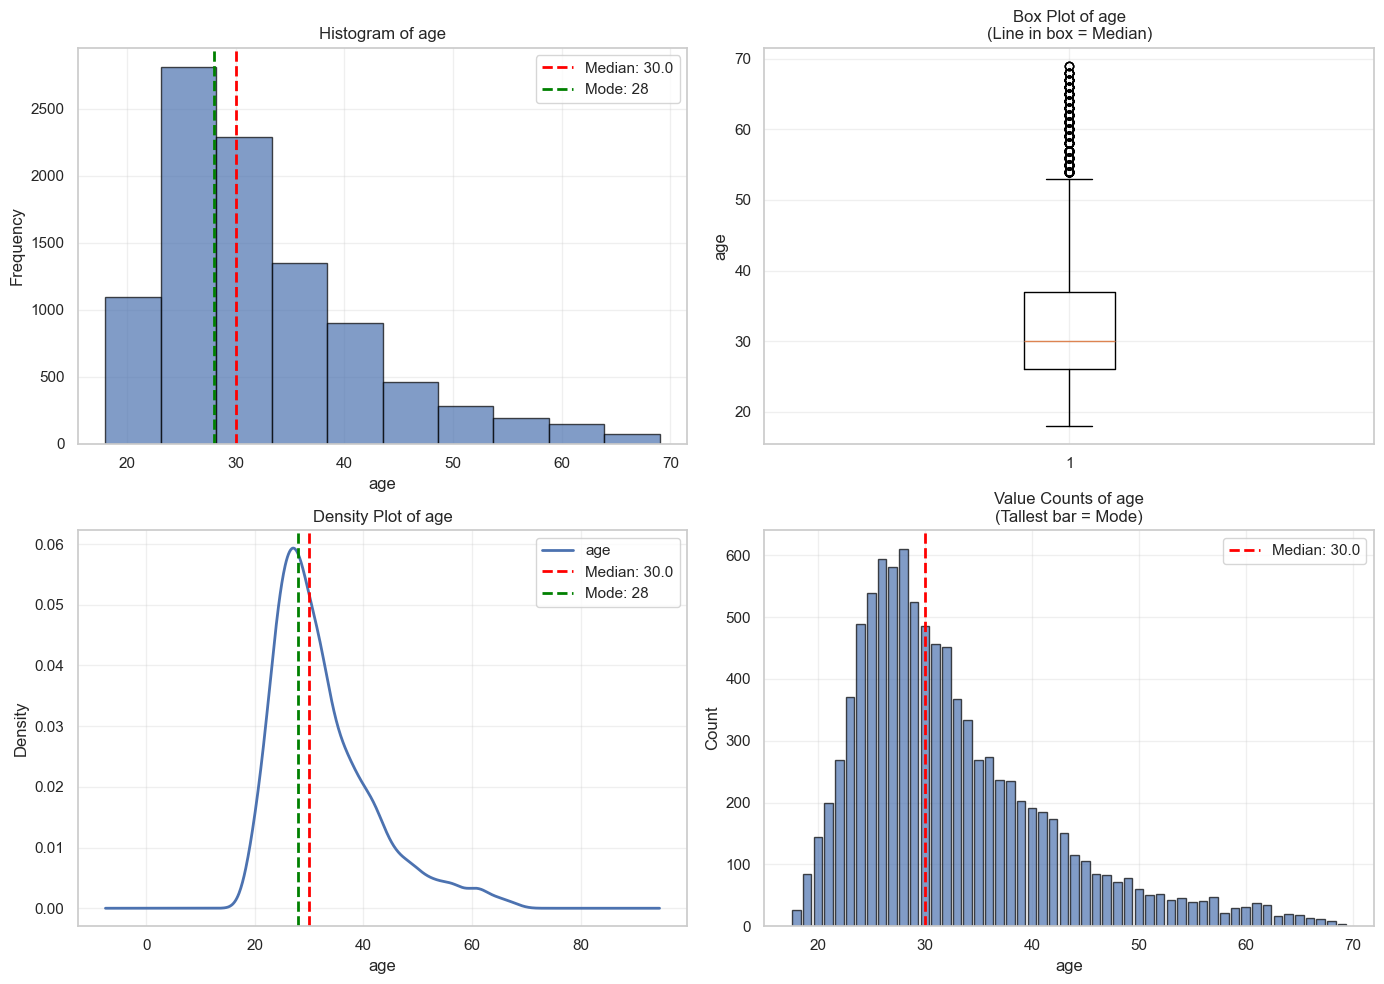

In [62]:
column_name = "age"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with median and mode lines
axes[0, 0].hist(df_clustered[column_name], bins=10, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(median_value, color='red', linestyle='--', linewidth=2, label=f'Median: {median_value}')
axes[0, 0].axvline(mode_value.values[0], color='green', linestyle='--', linewidth=2, label=f'Mode: {mode_value.values[0]}')
axes[0, 0].set_xlabel(column_name)
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Histogram of {column_name}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot (shows median clearly)
axes[0, 1].boxplot(df_clustered[column_name], vert=True)
axes[0, 1].set_ylabel(column_name)
axes[0, 1].set_title(f'Box Plot of {column_name}\n(Line in box = Median)')
axes[0, 1].grid(alpha=0.3)

# 3. KDE (Kernel Density Estimate) plot
df_clustered[column_name].plot(kind='kde', ax=axes[1, 0], linewidth=2)
axes[1, 0].axvline(median_value, color='red', linestyle='--', linewidth=2, label=f'Median: {median_value}')
axes[1, 0].axvline(mode_value.values[0], color='green', linestyle='--', linewidth=2, label=f'Mode: {mode_value.values[0]}')
axes[1, 0].set_xlabel(column_name)
axes[1, 0].set_title(f'Density Plot of {column_name}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Value counts bar chart (great for seeing mode)
value_counts = df_clustered[column_name].value_counts().sort_index()
axes[1, 1].bar(value_counts.index, value_counts.values, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(median_value, color='red', linestyle='--', linewidth=2, label=f'Median: {median_value}')
axes[1, 1].set_xlabel(column_name)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'Value Counts of {column_name}\n(Tallest bar = Mode)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
numeric_cols = ["age", "doc_len", "essay_len", "lex_div", "tfidf_entropy"]
def numeric_posthoc_analysis(df_clustered, cluster_col, numeric_cols):
    clusters = sorted(df_clustered[cluster_col].unique())
    desc = {}
    kruskal_results = {}
    # ---- Descriptive + Kruskal ----
    for col in numeric_cols:
        desc[col] = df_clustered.groupby(cluster_col)[col].agg(
            ["count","mean","median","std"]
        )
        groups = [
            df_clustered[df_clustered[cluster_col]==c][col].dropna().values
            for c in clusters
        ]
        stat, p = stats.kruskal(*groups)
        kruskal_results[col] = (stat, p)

    # ---- Pairwise Posthoc ----
    posthoc = {}
    for col in numeric_cols:
        stat, p = kruskal_results[col]
        if pd.isna(p) or p >= 0.05:
            continue
        pairs = []
        for a,b in itertools.combinations(clusters, 2):
            ga = df_clustered.loc[df_clustered[cluster_col]==a, col].dropna().values
            gb = df_clustered.loc[df_clustered[cluster_col]==b, col].dropna().values
            if len(ga)==0 or len(gb)==0:
                continue
            s, pval = stats.mannwhitneyu(ga, gb, alternative="two-sided")
            pairs.append(((a,b), pval))
        pairs_adj = [
            (pair, min(pv*len(pairs), 1.0))
            for pair,pv in pairs
        ]
        posthoc[col] = pairs_adj
    return desc, kruskal_results, posthoc
desc, kruskal_df, posthoc = numeric_posthoc_analysis(df_clustered, cluster_col, numeric_cols)

In [64]:
print(desc)


{'age':          count       mean  median        std
cluster                                     
-1        5110  32.019178    30.0   9.050197
 0          66  32.181818    29.0   9.888469
 1          63  41.952381    41.0  11.916955
 2        1608  31.362562    30.0   8.436358
 3          77  32.103896    30.0   8.141163
 4          79  29.670886    28.0   7.611937
 5          58  30.775862    28.5   7.608958
 6        2544  34.419025    32.0   9.973447, 'doc_len':          count         mean  median          std
cluster                                         
-1        5110  3621.008611  3175.0  2249.103434
 0          66  4376.803030  3870.5  2768.374598
 1          63  3943.888889  3508.0  1839.127932
 2        1608  3444.717040  3103.0  1815.104018
 3          77  3687.142857  3306.0  1860.084539
 4          79  4486.025316  3568.0  2924.798810
 5          58  3301.620690  3161.0   947.355670
 6        2544  3509.607704  3070.0  2038.808074, 'essay_len':          count        mean

In [65]:
print(kruskal_df)

{'age': (194.7325833703406, 1.4961694070975992e-38), 'doc_len': (29.108624686109533, 0.00013823412747857402), 'essay_len': (25.600847477657247, 0.0005934096995782542), 'lex_div': (116.10617900486044, 4.950267549103589e-22), 'tfidf_entropy': (15.288478981277876, 0.0324742814144431)}


In [66]:
print(posthoc)

{'age': [((-1, 0), 1.0), ((-1, 1), 6.59196733360792e-11), ((-1, 2), 1.0), ((-1, 3), 1.0), ((-1, 4), 0.8453346588050757), ((-1, 5), 1.0), ((-1, 6), 3.5636556224542437e-25), ((0, 1), 5.3136660820920974e-05), ((0, 2), 1.0), ((0, 3), 1.0), ((0, 4), 1.0), ((0, 5), 1.0), ((0, 6), 1.0), ((1, 2), 3.8833350491971395e-12), ((1, 3), 5.494174552912776e-06), ((1, 4), 3.592919413565782e-09), ((1, 5), 3.3155184739584857e-07), ((1, 6), 3.962109483143428e-06), ((2, 3), 1.0), ((2, 4), 1.0), ((2, 5), 1.0), ((2, 6), 7.897695569353342e-22), ((3, 4), 1.0), ((3, 5), 1.0), ((3, 6), 1.0), ((4, 5), 1.0), ((4, 6), 0.0003138290314697382), ((5, 6), 0.0915708396671071)], 'doc_len': [((-1, 0), 0.9190261689866364), ((-1, 1), 1.0), ((-1, 2), 1.0), ((-1, 3), 1.0), ((-1, 4), 0.6693595289280301), ((-1, 5), 1.0), ((-1, 6), 0.03190082930373682), ((0, 1), 1.0), ((0, 2), 0.27261869910029396), ((0, 3), 1.0), ((0, 4), 1.0), ((0, 5), 1.0), ((0, 6), 0.23675020586933057), ((1, 2), 0.5335784967351749), ((1, 3), 1.0), ((1, 4), 1.0)

***Analysis:-***

1. Age

p = 1.49e-38 = significant. 

Significant pairwise differences were heavily driven by **Cluster 1** and **Cluster 6**, which sharply diverge from the rest of the pack. Differences were observed between:
- Cluster 1 and Clusters -1, 0, 2, 3, 4, 5, and 6
- Cluster 6 and Clusters -1, 2, and 4

This indicates that Cluster 1 and Cluster 6 represent highly distinct demographic age groups compared to the other users. Meanwhile, the ages of users in Clusters 0, 2, 3, 4, and 5 largely overlap with one another, showing no statistical difference.

2. Document Length

p = 0.000138 = significant (globally).

Despite the global test indicating an overall variance in document lengths, the rigorous pairwise post-hoc test found almost no significant differences between specific clusters after adjusting for multiple comparisons. 

The *only* significant pairwise difference observed was between:
- Cluster -1 and Cluster 6 (p = 0.031)

This suggests that while there are slight average fluctuations, document length is heavily standardized across the main personality clusters. No specific personality type writes drastically longer or shorter overall profiles than the others.

3. Essay Length

p = 0.000593 = significant (globally).

Mirroring the document length results, the global significance completely disappears when comparing individual groups side-by-side with strict statistical penalties applied.

Significant pairwise differences:
- **None.** (All adjusted p-values are > 0.05, mostly 1.0).

This definitively confirms that the actual word count of the individual essays does not meaningfully define or separate any of the latent personality clusters from each other. They all write roughly the same amount.

4. Lexical Diversity

p = 4.95e-22 = significant.

Lexical diversity is one of the absolute strongest separators of the clusters. Significant pairwise differences were massively driven by **Cluster 5**, which stands completely alone, and **Cluster 2**. Differences were observed between:
- Cluster 5 and Clusters -1, 0, 1, 2, 3, 4, and 6 
- Cluster 2 and Clusters -1, 3, and 6
- Cluster -1 and Cluster 3

This indicates that Cluster 5 uses a completely unique level of vocabulary richness compared to the entire rest of the dating pool. Cluster 2 also exhibits highly distinct, likely more repetitive, vocabulary patterns compared to several other groups.

5. TF-IDF Entropy

p = 0.032 = significant (globally).

Although the global test indicated a marginally significant difference across all the groups overall, the pairwise post-hoc tests revealed that there are no significant pairwise differences between any specific clusters.

The strongest difference observed was between Cluster -1 and Cluster 2 (p ≈ 0.186), which is still well above the 0.05 significance threshold.

Almost all other cluster pairings resulted in an adjusted p-value of 1.0.

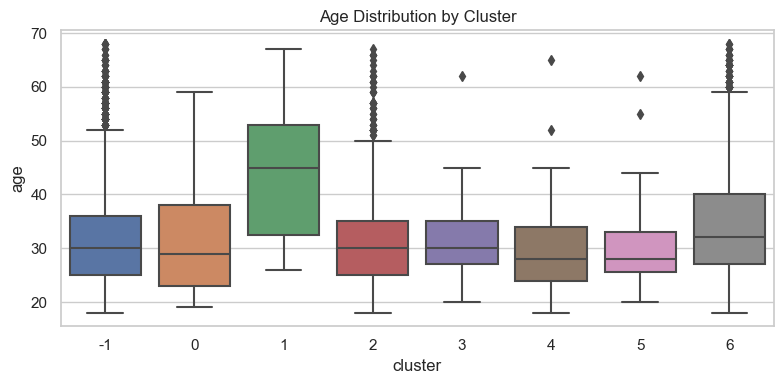

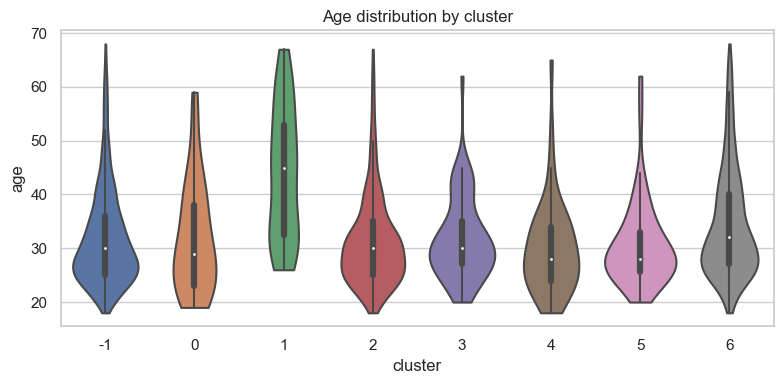

In [85]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_clustered, x=cluster_col, y="age")
plt.title("Age Distribution by Cluster")
plt.tight_layout()
plt.show()

# violin for distribution
plt.figure(figsize=(8,4))
sns.violinplot(x=cluster_col, y="age", data=df_clustered, cut=0)
plt.title("Age distribution by cluster")
plt.tight_layout()
plt.show()


#### Categorical Variables Analysis

In [68]:
cat_cols = ["education","job","drinks","smokes","drugs","diet","religion","sex","orientation","body_type","pets"]
missgre10 = []
grp_cols = []
for col in cat_cols:
    total_rows = len(df_clustered)
    missing_count = df_clustered[col].isna().sum()
    unique_count = df_clustered[col].nunique()
    mode_val = df_clustered[col].mode()[0] if not df_clustered[col].mode().empty else 'N/A'
    
    print(f"\n{'='*50}")
    print(f" 📊 COLUMN: {col.upper()}")
    print(f"{'='*50}")
    if unique_count >= 10:
        grp_cols.append(col)
    print(f" • Unique Values : {unique_count}")
    
    if (missing_count / total_rows)*100 >= 10:
        missgre10.append(col)
    print(f" • Missing Values: {missing_count} ({(missing_count / total_rows) * 100:.2f}%)")
    print(f" • Most Common   : {mode_val}\n")

    print(" • Top Value Distribution:")
    counts = df_clustered[col].value_counts()
    percentages = df_clustered[col].value_counts(normalize=True) * 100

    dist_df = pd.DataFrame({
        'Count': counts, 
        'Percentage (%)': percentages
    }).round(2)

    print(dist_df.head(10).to_string())

    if unique_count > 10:
        print(f" ... (showing top 10 of {unique_count} unique values)")



 📊 COLUMN: EDUCATION
 • Unique Values : 31
 • Missing Values: 560 (5.83%)
 • Most Common   : graduated from college/university

 • Top Value Distribution:
                                   Count  Percentage (%)
education                                               
graduated from college/university   3951           43.68
graduated from masters program      1527           16.88
working on college/university       1052           11.63
working on masters program           318            3.52
graduated from two-year college      237            2.62
working on two-year college          223            2.47
dropped out of college/university    215            2.38
working on ph.d program              211            2.33
graduated from ph.d program          193            2.13
graduated from law school            184            2.03
 ... (showing top 10 of 31 unique values)

 📊 COLUMN: JOB
 • Unique Values : 21
 • Missing Values: 712 (7.41%)
 • Most Common   : other

 • Top Value Distributi

In [69]:
print(missgre10)

['drugs', 'diet', 'religion', 'pets']


With missing percentage less than 10% we will be dropping those cols and doing the analysis however for the ones greater than 10% we will be separately encoding the missing values as a missing categor, in order to preserve sample size and capture potential behavioral signaling inherent in non-disclosure.

In [70]:
for col in missgre10:
    df_clustered[col] = df_clustered[col].fillna("Missing")

df_clustered = df_clustered.dropna(subset=cat_cols)

In [71]:
for col in cat_cols:
    total_rows = len(df_clustered)
    missing_count = df_clustered[col].isna().sum()
    print(f" 📊 COLUMN: {col.upper()}")
    print(f" • Missing Values: {missing_count} ({(missing_count / total_rows) * 100:.2f}%)")

 📊 COLUMN: EDUCATION
 • Missing Values: 0 (0.00%)
 📊 COLUMN: JOB
 • Missing Values: 0 (0.00%)
 📊 COLUMN: DRINKS
 • Missing Values: 0 (0.00%)
 📊 COLUMN: SMOKES
 • Missing Values: 0 (0.00%)
 📊 COLUMN: DRUGS
 • Missing Values: 0 (0.00%)
 📊 COLUMN: DIET
 • Missing Values: 0 (0.00%)
 📊 COLUMN: RELIGION
 • Missing Values: 0 (0.00%)
 📊 COLUMN: SEX
 • Missing Values: 0 (0.00%)
 📊 COLUMN: ORIENTATION
 • Missing Values: 0 (0.00%)
 📊 COLUMN: BODY_TYPE
 • Missing Values: 0 (0.00%)
 📊 COLUMN: PETS
 • Missing Values: 0 (0.00%)


In [72]:
print(grp_cols)

['education', 'job', 'diet', 'religion', 'body_type', 'pets']


In [73]:
grp_cols.remove("body_type")

Next some cols like religion (45 categories) and education (31 categories), chi-square can become unstable. we will grouping them into broad categories. 

In [74]:
for i in grp_cols:
    print(f"--------------{i}----------------")
    print(df_clustered[i].value_counts())

--------------education----------------
education
graduated from college/university    3193
graduated from masters program       1264
working on college/university         902
working on masters program            253
graduated from two-year college       208
working on two-year college           185
dropped out of college/university     174
graduated from ph.d program           167
working on ph.d program               165
graduated from high school            156
graduated from law school             148
graduated from space camp             114
dropped out of space camp              92
college/university                     84
working on space camp                  68
graduated from med school              50
dropped out of two-year college        30
working on law school                  29
working on med school                  29
dropped out of masters program         28
dropped out of ph.d program            21
two-year college                       18
dropped out of high school

In [75]:
def simplify_pets(x):
    if pd.isna(x) or x == "Missing":
        return "Missing"
    
    x = x.lower()
    
    # Likes both (strongest first)
    if (
        "likes dogs and likes cats" in x
        or "has dogs and has cats" in x
        or "has dogs and likes cats" in x
        or "likes dogs and has cats" in x
    ):
        return "Likes Both"
    
    # Dog only group
    if (
        "likes dogs and dislikes cats" in x
        or "has dogs and dislikes cats" in x
        or x == "likes dogs"
        or x == "has dogs"
    ):
        return "Likes Only Dogs"
    
    # Cat only group
    if (
        "dislikes dogs and likes cats" in x
        or x == "likes cats"
        or x == "has cats"
        or x == "dislikes dogs and has cats"  
    ):
        return "Likes Only Cats"
    
    # Remaining dislikes dogs only
    if (x == "dislikes dogs" or x == "dislikes cats" 
        or "dislikes dogs and dislikes cats" in x):
        return "Dislikes Both"
    
    return "Other"

df_clustered["pets_group"] = df_clustered["pets"].apply(simplify_pets)

def simplify_job(x):
    if pd.isna(x):
        return "Missing"
    
    x = x.lower()
    
    if "software" in x or "tech" in x or "engineering" in x:
        return "Tech"
    elif "artist" in x or "musical" in x or "writer" in x or "media" in x:
        return "Creative"
    elif "marketing" in x or "sales" in x or "executive" in x or "financial" in x:
        return "Business"
    elif "education" in x or "academia" in x:
        return "Education"
    elif "medicine" in x or "health" in x:
        return "Healthcare"
    elif "law" in x:
        return "Legal"
    elif "government" in x or "political" in x:
        return "Government"
    elif "student" in x:
        return "Student"
    else:
        return "Other"

df_clustered["job_group"] = df_clustered["job"].apply(simplify_job)

def simplify_diet(x):
    if pd.isna(x):
        return "Missing"
    
    x = x.lower()
    
    if "vegetarian" in x:
        return "Vegetarian"
    elif "vegan" in x:
        return "Vegan"
    elif "kosher" in x or "halal" in x:
        return "Religious Diet"
    elif "anything" in x:
        return "Omnivore"
    elif "other" in x:
        return "Other"
    else:
        return "Other"

df_clustered["diet_group"] = df_clustered["diet"].apply(simplify_diet)

def simplify_religion(x):
    if pd.isna(x) or x == "Missing":
        return "Missing"
    
    x = x.lower()
    
    if "atheism" in x:
        return "Atheist"
    elif "agnosticism" in x:
        return "Agnostic"
    elif "christianity" in x or "catholicism" in x:
        return "Christian"
    elif "judaism" in x:
        return "Jewish"
    elif "buddhism" in x:
        return "Buddhist"
    elif "hinduism" in x:
        return "Hindu"
    elif "islam" in x:
        return "Muslim"
    elif "other" in x:
        return "Other"
    else:
        return "Other"

df_clustered["religion_group"] = df_clustered["religion"].apply(simplify_religion)

def simplify_education(x):
    if pd.isna(x) or x == "Missing":
        return "Missing"
    
    x = x.lower()
    
    if "ph.d" in x:
        return "Doctorate"
    elif "med school" in x or "law school" in x:
        return "Professional"
    elif "masters" in x:
        return "Master's"
    elif "college/university" in x:
        if "working" in x or "dropped" in x:
            return "Some College"
        else:
            return "Bachelor's"
    elif "two-year college" in x:
        return "Some College"
    elif "high school" in x:
        return "High School or Below"
    else:
        return "Other"

df_clustered["education_group"] = df_clustered["education"].apply(simplify_education)


In [76]:
for col in grp_cols:
    print(df_clustered[col+"_group"].value_counts(normalize=True))

education_group
Bachelor's              0.441169
Master's                0.209074
Some College            0.204227
Doctorate               0.048196
Other                   0.038099
Professional            0.034868
High School or Below    0.024367
Name: proportion, dtype: float64
job_group
Other         0.224825
Tech          0.195746
Business      0.149031
Creative      0.139472
Student       0.102854
Education     0.080506
Healthcare    0.068659
Legal         0.024367
Government    0.014540
Name: proportion, dtype: float64
diet_group
Omnivore          0.531637
Other             0.355412
Vegetarian        0.095315
Vegan             0.014943
Religious Diet    0.002693
Name: proportion, dtype: float64
religion_group
Agnostic     0.197496
Missing      0.188207
Other        0.170840
Christian    0.166667
Atheist      0.163974
Jewish       0.060582
Buddhist     0.044965
Hindu        0.005924
Muslim       0.001346
Name: proportion, dtype: float64
pets_group
Likes Both         0.535541
Likes 

In religion - muslim and hindu percentages are very less which might cause some imbalances in chi square test {insert chi square formula} That violates the expected ≥ 5 rule in multiple cells.
whereas in pets "Dislikes Both" Even if its tiny:

It does not distort interpretation of major pet-preference trends

A category is too small to produce stable inference AND its separation does not add theoretical value.

In [77]:
df_clustered["religion_group"] = df_clustered["religion_group"].replace(
    {"Hindu": "Other", 
     "Muslim": "Other"}
)

print(df_clustered["religion_group"].value_counts(normalize=True))

religion_group
Agnostic     0.197496
Missing      0.188207
Other        0.178110
Christian    0.166667
Atheist      0.163974
Jewish       0.060582
Buddhist     0.044965
Name: proportion, dtype: float64


In [78]:
from scipy.stats import chi2_contingency

def cramers_v(tab):
    chi2, p, dof, expected = chi2_contingency(tab)
    n = tab.sum().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

results = {}

for col in cat_cols:
    tab = pd.crosstab(df_clustered[cluster_col], df_clustered[col])
    
    chi2, p, dof, expected = chi2_contingency(tab)
    cv = cramers_v(tab)
    
    results[col] = {
        "chi2_p": p,
        "cramers_v": cv
    }

pd.DataFrame(results).T.sort_values("cramers_v", ascending=False)

,chi2_p,cramers_v
orientation,1.235189e-20,0.087874
religion,1.323444e-28,0.083163
drugs,4.219139e-10,0.054667
sex,3.655386e-04,0.051601
job,3.944323e-09,0.047857
diet,1.051054e-09,0.047403
pets,3.816351e-10,0.047045
education,7.457320e-05,0.040558
smokes,2.919299e-06,0.040053
body_type,4.982378e-07,0.038407


Categorical analysis reveals that sexual orientation is the strongest demographic correlate of the essay-based clusters (Cramer's V = 0.08), indicating that linguistic patterns are meaningfully structured by identity orientation. Features further down the list (like Diet, Drinks, or Drugs) likely have Cramer's V scores hovering around 0.05. While statistically significant, they don't strongly define the clusters.

In [79]:
def top_lifts(col, top_n=3):
    tab = pd.crosstab(df_clustered[cluster_col], df_clustered[col])
    overall = df_clustered[col].value_counts(normalize=True)

    lifts = {}
    for cl in tab.index:
        cluster_total = tab.loc[cl].sum()
        prop_cluster = tab.loc[cl] / cluster_total
        lift = (prop_cluster / overall).sort_values(ascending=False)
        lifts[cl] = lift.head(top_n)
    return lifts

# Example
for col in cat_cols:
    print(top_lifts(col))


{-1: education
dropped out of law school    1.887195
space camp                   1.258130
working on law school        1.171362
dtype: float64, 0: education
working on med school         9.314107
two-year college              7.503030
graduated from high school    3.462937
dtype: float64, 1: education
dropped out of masters program     6.169435
graduated from ph.d program        3.103189
graduated from two-year college    2.491503
dtype: float64, 2: education
law school         6.098522
ph.d program       2.439409
masters program    2.286946
dtype: float64, 3: education
two-year college             6.655914
working on space camp        3.523719
graduated from med school    2.396129
dtype: float64, 4: education
working on high school             16.183007
working on law school               5.022312
dropped out of two-year college     4.854902
dtype: float64, 5: education
working on masters program     3.748045
working on ph.d program        1.915667
working on two-year college    1.70

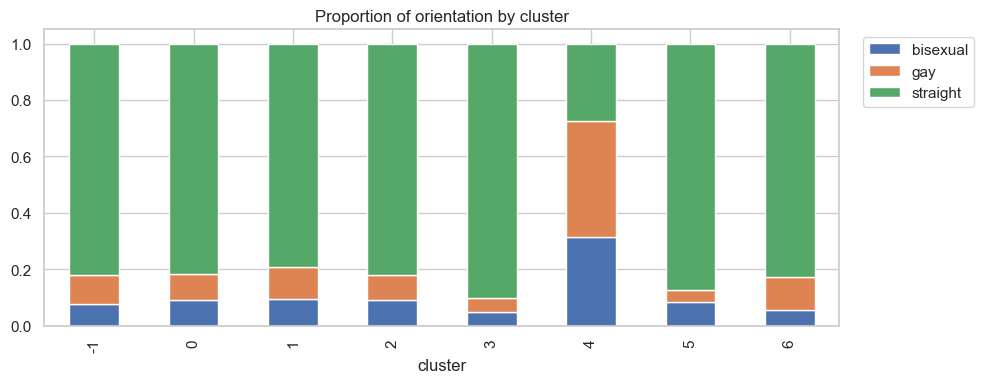

In [80]:
col = "orientation" 
ct = pd.crosstab(df_clustered[cluster_col], df_clustered[col])
props = ct.div(ct.sum(axis=1), axis=0).fillna(0)
props.plot(kind="bar", stacked=True, figsize=(10,4))
plt.title(f"Proportion of {col} by cluster")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

#### Noise / discarded profiles diagnostics

In [81]:
# D) noise analysis: if HDBSCAN noise is -1
noise_mask = edf_all[cluster_col] == -1
n_noise = noise_mask.sum()
print("Noise count:", n_noise, "percentage:", n_noise / len(edf_all))

# compare mean doc length, tfidf_entropy, num_meaningful_essays
diag_cols = ["doc_len","essay_len","num_meaningful_essays","tfidf_entropy","lex_div"]
diag_cols = [c for c in diag_cols if c in edf_all.columns]
noise_stats = edf_all.loc[noise_mask, diag_cols].agg(["count","mean","median","std"])
clustered_stats = edf_all.loc[~noise_mask, diag_cols].agg(["count","mean","median","std"])
print("Noise stats:\n", noise_stats)
print("Clustered stats:\n", clustered_stats)

# sample a few noise docs to inspect
print("\nExample noisy documents (first 10):")
for t in edf_all.loc[noise_mask, "clean_essay"].head(10).tolist():
    print("----")
    print(t[:400])


Noise count: 5110 percentage: 0.5320145757418011
Noise stats:
             doc_len    essay_len  num_meaningful_essays  tfidf_entropy  \
count   5110.000000  5110.000000                 5110.0    5110.000000   
mean    3621.008611   686.077495                   10.0       5.399633   
median  3175.000000   601.000000                   10.0       5.405932   
std     2249.103434   419.708042                    0.0       0.402887   

            lex_div  
count   5110.000000  
mean       0.541712  
median     0.539130  
std        0.075950  
Clustered stats:
             doc_len    essay_len  num_meaningful_essays  tfidf_entropy  \
count   4495.000000  4495.000000                 4495.0    4495.000000   
mean    3522.732147   668.721913                   10.0       5.380360   
median  3102.000000   587.000000                   10.0       5.391226   
std     1984.698746   375.085561                    0.0       0.409104   

            lex_div  
count   4495.000000  
mean       0.539587  
m

Noise has:

Medium length

Medium lexical diversity

Medium entropy

This supports  earlier idea:

Noise is not random garbage — it is semantically mixed users.

#### Let's Visualise

In [87]:
print(df_clustered.keys())

Index(['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0',
       'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7',
       'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job',
       'last_online', 'location', 'offspring', 'orientation', 'pets',
       'religion', 'sex', 'sign', 'smokes', 'speaks', 'status', 'full_essay',
       'clean_essay', 'doc_len', 'hdbscan_label', 'essay_len', 'lex_div',
       'tfidf_entropy', 'cluster', 'pets_group', 'job_group', 'diet_group',
       'religion_group', 'education_group'],
      dtype='object')


Analyse the code 

In [90]:
import pandas as pd
import plotly.express as px
import textwrap

# 1. Format the FULL list of texts
wrapped_texts = [
    textwrap.fill(str(txt)[:300] + "...", width=60).replace('\n', '<br>') 
    for txt in texts
]

# 2. Build the DataFrame using your longer, full-length arrays
plot_df = pd.DataFrame({
    'umap_x': umap_2d[:, 0],
    'umap_y': umap_2d[:, 1],
    'Profile Snippet': wrapped_texts
})

# 3. THE MAGIC STEP: Map the labels over. 
# Pandas will automatically align them based on their original row index!
plot_df['Cluster_ID'] = df_clustered['cluster']

# 4. Drop the rows that didn't get a label (the ones that were filtered out earlier)
plot_df = plot_df.dropna(subset=['Cluster_ID'])

# 5. Format the labels cleanly for the plot legend
plot_df['Cluster'] = plot_df['Cluster_ID'].apply(
    lambda x: "Noise" if x == -1 else f"Cluster {int(x)}"
)

# 6. Generate the Interactive Plot
fig = px.scatter(
    plot_df, 
    x='umap_x', 
    y='umap_y', 
    color='Cluster',
    hover_data={'umap_x': False, 'umap_y': False, 'Cluster': True, 'Profile Snippet': True, 'Cluster_ID': False},
    title="Latent Personality Clusters in OKCupid Profiles (UMAP Projection)",
    color_discrete_sequence=px.colors.qualitative.Bold
)

# 7. Portfolio Polish
fig.update_layout(
    template="plotly_white",
    title_font_size=22,
    legend_title="Assigned Category",
    width=1000, 
    height=750,
    hoverlabel=dict(font_size=14, font_family="Arial")
)

fig.update_traces(marker=dict(size=3, opacity=0.6))

# Show the plot!
fig.show()

# Save for your portfolio
fig.write_html("interactive_dating_clusters.html")

Although a noise point and a point classfied into a cluster here might be close visually but the point classified as noise might not have close neighbours to be classified into a cluster.

#### Summary 

In [ ]:
# E) create simple summary table
summary_rows = []
for cl in sorted(edf_all[cluster_col].unique()):
    subset = edf_all[edf_all[cluster_col]==cl]
    summary_rows.append({
        "cluster": cl,
        "n": len(subset),
        "median_doc_len": subset["doc_len"].median(),
        "median_tf_entropy": subset["tfidf_entropy"].median(),
        "median_lex_div": subset["lex_div"].median()
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("cluster_summary_basic.csv", index=False)
print("Saved cluster_summary_basic.csv")


Saved cluster_summary_basic.csv


### Final Takeaway from this project + Future Direction

***Key Takeaways:***







***Future Directions:***

+ Right now MPNet model was used as  the sentence transformer to get the embeddings of the essays. My average length of the esssays for each user was ~670 word which requires approximately 1000 tokens but MPNet supports only upto 512 tokens at max which causes only half of each of the essay to be read and generate embeddings. In the future much stronger and bigger models could be used which might actually reduce the noise profile on doing HDBSCAN.
+ More analysis can be conducted on to why almost 52% of the dataset users were categorised as noise. Were they just equally fitting into all clusters or did they not have any unique traits or have extreme characteristics which they share with no one or if the HDBScan model needs to be tuned down to allow more error into the clusters.

### Conclusion